# 🔆 Solar Power Plant Analysis

**Data analisis dan forecasting untuk Solar Power Plant**

📋 **Fitur:**
- Data loading dengan format European 
- Feature engineering (lag, time encoding)
- 3 ML models (Baseline, Linear Regression, Random Forest)
- Forecasting dengan confidence intervals
- Export ke Excel

In [1]:
# Import libraries
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
print("📚 Libraries loaded")

📚 Libraries loaded


## 1. Data Loading

In [2]:
def _to_float(val):
    """Convert European format to float"""
    if pd.isna(val) or val == '':
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        val = val.strip().replace('.', '').replace(',', '.')
        try:
            return float(val)
        except:
            return np.nan
    return np.nan

def load_data():
    """Load dan preprocess data"""
    # Cari file new.xlsx
    files = [f for f in os.listdir('.') if 'new' in f and f.endswith('.xlsx')]
    if not files:
        print("❌ File new.xlsx tidak ditemukan")
        return None
    
    file = files[0]
    print(f"📁 Loading: {file}")
    
    # Read Excel
    df = pd.read_excel(file)
    print(f"📊 Shape: {df.shape}")
    
    # Parse datetime dan numerik
    for col in df.columns:
        if 'date' in col.lower() or 'time' in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')
        elif df[col].dtype == 'object':
            df[col] = df[col].apply(_to_float)
    
    return df

# Load data
data = load_data()

📁 Loading: Solar Power Plant Data XLSX new.xlsx
📊 Shape: (744, 17)
📊 Shape: (744, 17)


In [3]:
# Load data using our function
data = load_data()

if data is not None:
    print(f"✅ Data loaded successfully!")
    print(f"📊 Columns: {list(data.columns)}")
else:
    print("❌ Failed to load data - check if new.xlsx file exists")

📁 Loading: Solar Power Plant Data XLSX new.xlsx
📊 Shape: (744, 17)
✅ Data loaded successfully!
📊 Columns: ['Date Hour (NMT)', 'Wind Speed', 'Sunshine', 'Air Pressure', 'Radiation', 'Air Temperature', 'Relative Air Humidity', 'System Production', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']


In [4]:
def add_features(df, datetime_col, target_col):
    """Add all necessary features"""
    print("⚙️ Adding features...")
    
    # Time features
    df['hour'] = df[datetime_col].dt.hour
    df['month'] = df[datetime_col].dt.month
    df['weekday'] = df[datetime_col].dt.weekday
    
    # Circular encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Solar features
    df['is_daylight'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)
    
    # Lag features (only if target column exists)
    if target_col in df.columns:
        for lag in [1, 3, 6, 24]:
            df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
        
        # Rolling features
        for window in [6, 24]:
            df[f'{target_col}_rolling_{window}'] = df[target_col].rolling(window).mean()
    
    print(f"✅ Features added. Shape: {df.shape}")
    return df

# Identifikasi datetime dan target columns
datetime_col = [col for col in data.columns if 'date' in col.lower() or 'time' in col.lower()][0]
# Find power column - it might be System Production
power_cols = [col for col in data.columns if 'power' in col.lower() or 'production' in col.lower() or 'system' in col.lower()]
target_col = power_cols[0] if power_cols else 'System Production'

print(f"📅 Datetime column: {datetime_col}")
print(f"🎯 Target column: {target_col}")

# Add features
data = add_features(data, datetime_col, target_col)

📅 Datetime column: Date Hour (NMT)
🎯 Target column: System Production
⚙️ Adding features...
✅ Features added. Shape: (744, 30)
✅ Features added. Shape: (744, 30)


📊 Dataset Info:
Shape: (744, 30)
Date range: 2017-01-01 00:00:00 to 2017-12-01 23:00:00
Target stats: min=0.00, max=16063333.00


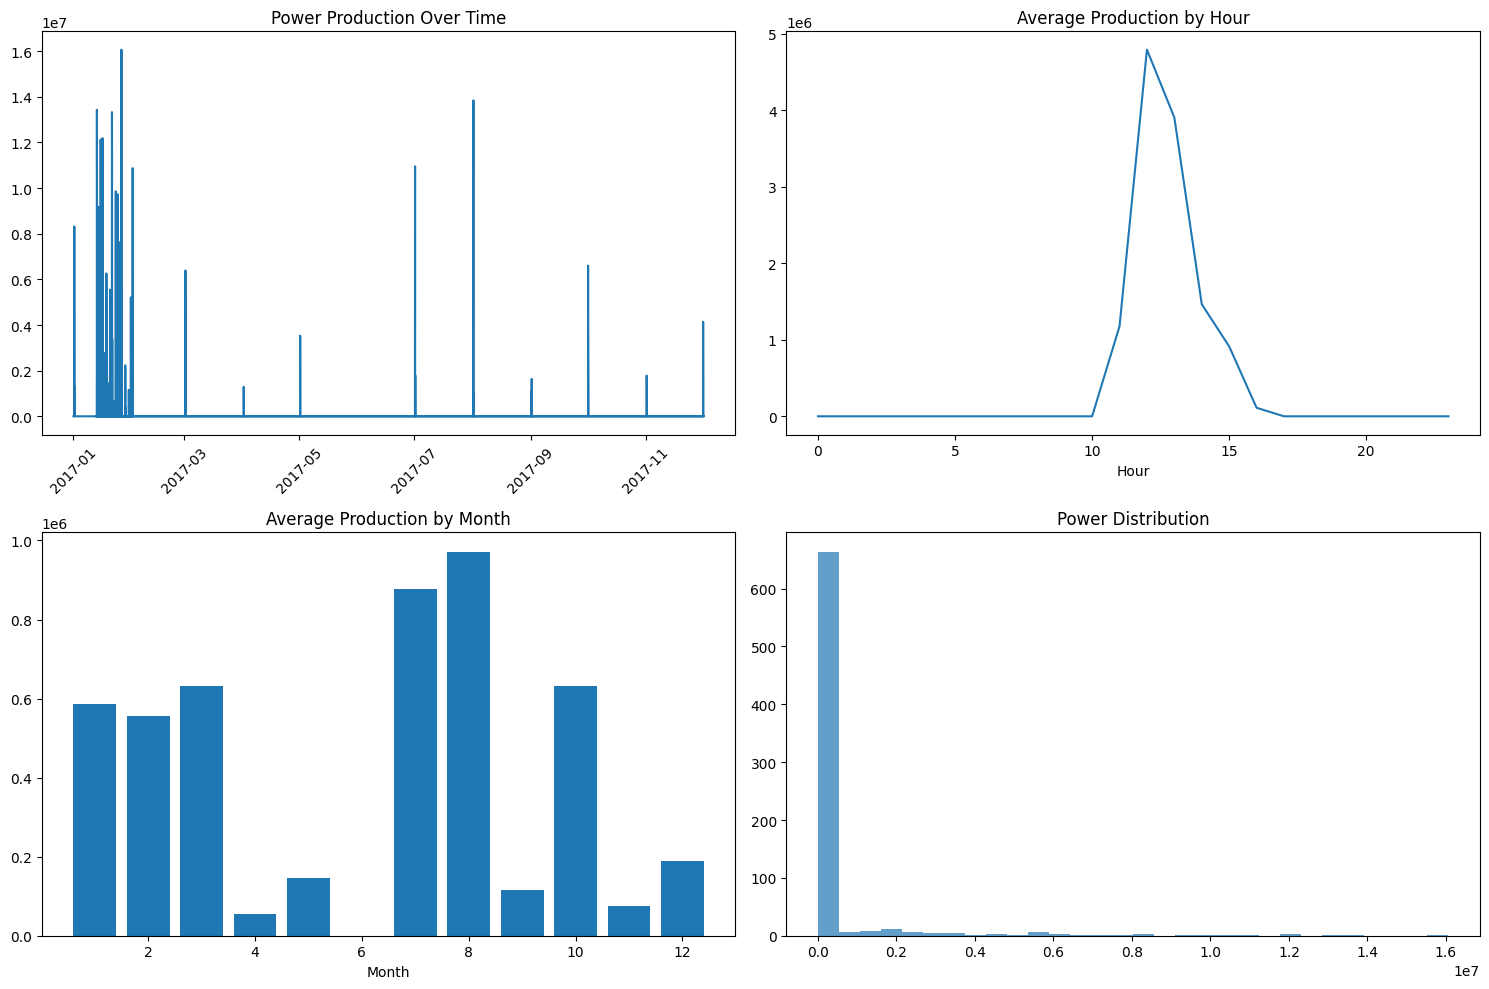

In [5]:
# Quick EDA
print("📊 Dataset Info:")
print(f"Shape: {data.shape}")
print(f"Date range: {data[datetime_col].min()} to {data[datetime_col].max()}")
print(f"Target stats: min={data[target_col].min():.2f}, max={data[target_col].max():.2f}")

# Basic plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series plot
axes[0,0].plot(data[datetime_col], data[target_col])
axes[0,0].set_title('Power Production Over Time')
axes[0,0].tick_params(axis='x', rotation=45)

# Hourly pattern
hourly = data.groupby('hour')[target_col].mean()
axes[0,1].plot(hourly.index, hourly.values)
axes[0,1].set_title('Average Production by Hour')
axes[0,1].set_xlabel('Hour')

# Monthly pattern
monthly = data.groupby('month')[target_col].mean()
axes[1,0].bar(monthly.index, monthly.values)
axes[1,0].set_title('Average Production by Month')
axes[1,0].set_xlabel('Month')

# Distribution
axes[1,1].hist(data[target_col].dropna(), bins=30, alpha=0.7)
axes[1,1].set_title('Power Distribution')

plt.tight_layout()
plt.show()

## 3. Model Training

In [6]:
# Debug: Check for NaN values
print("🔍 Checking for NaN values...")
print(f"Data columns with NaN: {data.isna().sum().sum()}")

# Prepare features (only use numeric features to avoid issues)
feature_cols = [col for col in data.columns if col not in [datetime_col, target_col] and data[col].dtype in ['float64', 'int64']]
model_data = data[[datetime_col, target_col] + feature_cols].copy()

print(f"📊 Using {len(feature_cols)} features")
print(f"Feature columns: {feature_cols[:5]}...")  # Show first 5

# Simple approach: drop rows with any NaN
model_data = model_data.dropna()

print(f"📊 Clean data shape: {model_data.shape}")

if len(model_data) < 50:
    print("❌ Too little data after cleaning. Using simple features only.")
    # Use only basic features
    basic_features = ['hour', 'month', 'weekday', 'is_daylight', 'is_weekend']
    available_basic = [col for col in basic_features if col in data.columns]
    model_data = data[[datetime_col, target_col] + available_basic].dropna()
    feature_cols = available_basic

print(f"📊 Final data shape: {model_data.shape}")

# Train/test split (90%/10%)
train_size = int(0.9 * len(model_data))
X_train = model_data[feature_cols][:train_size]
y_train = model_data[target_col][:train_size]
X_test = model_data[feature_cols][train_size:]
y_test = model_data[target_col][train_size:]

print(f"📈 Train: {len(X_train)} records")
print(f"📉 Test: {len(X_test)} records")

# Model 1: Simple hourly average baseline
hourly_avg = model_data.groupby('hour')[target_col].mean()[:train_size]
baseline_pred = []
for hour in X_test['hour']:
    baseline_pred.append(hourly_avg.get(hour, y_train.mean()))

# Model 2: Random Forest (skip Linear Regression for now)
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Evaluate models
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'name': name, 'MAE': mae, 'R2': r2}

results = [
    evaluate_model(y_test, baseline_pred, 'Hourly Baseline'),
    evaluate_model(y_test, rf_pred, 'Random Forest')
]

# Print results
print("\n🏆 Model Performance:")
for r in results:
    print(f"{r['name']}: MAE={r['MAE']:.0f}, R²={r['R2']:.3f}")

best_model = max(results, key=lambda x: x['R2'])
print(f"\n🥇 Best model: {best_model['name']} (R²={best_model['R2']:.3f})")

🔍 Checking for NaN values...
Data columns with NaN: 6752
📊 Using 25 features
Feature columns: ['Wind Speed', 'Sunshine', 'Air Pressure', 'Radiation', 'Air Temperature']...
📊 Clean data shape: (0, 27)
❌ Too little data after cleaning. Using simple features only.
📊 Final data shape: (744, 7)
📈 Train: 669 records
📉 Test: 75 records

🏆 Model Performance:
Hourly Baseline: MAE=416927, R²=-0.583
Random Forest: MAE=381502, R²=-1.123

🥇 Best model: Hourly Baseline (R²=-0.583)


## 4. Forecasting

In [7]:
# Simple 24-hour forecast using best model
forecast_hours = 24
last_timestamp = model_data[datetime_col].iloc[-1]

# Generate future timestamps
future_times = []
for i in range(1, forecast_hours + 1):
    future_times.append(last_timestamp + pd.Timedelta(hours=i))

# Create future features
forecast_data = []
for dt in future_times:
    features = {col: 0 for col in feature_cols}  # Initialize with zeros
    features['hour'] = dt.hour
    features['month'] = dt.month  
    features['weekday'] = dt.weekday()
    features['hour_sin'] = np.sin(2 * np.pi * dt.hour / 24)
    features['hour_cos'] = np.cos(2 * np.pi * dt.hour / 24)
    features['is_daylight'] = 1 if 6 <= dt.hour <= 18 else 0
    features['is_weekend'] = 1 if dt.weekday() >= 5 else 0
    
    # Use recent values for lag features (simplified)
    recent_vals = model_data[target_col].tail(24).values
    if len(recent_vals) >= 24:
        features[f'{target_col}_lag_24'] = recent_vals[-24]
    if len(recent_vals) >= 6:
        features[f'{target_col}_lag_6'] = recent_vals[-6]
    if len(recent_vals) >= 3:
        features[f'{target_col}_lag_3'] = recent_vals[-3] 
    if len(recent_vals) >= 1:
        features[f'{target_col}_lag_1'] = recent_vals[-1]
        
    # Rolling features
    features[f'{target_col}_rolling_6'] = recent_vals[-6:].mean() if len(recent_vals) >= 6 else recent_vals.mean()
    features[f'{target_col}_rolling_24'] = recent_vals.mean()
    
    forecast_data.append(features)

# Convert to DataFrame
forecast_df = pd.DataFrame(forecast_data)

# Make forecast using best model
if best_model['name'] == 'Random Forest':
    forecast_pred = rf_model.predict(forecast_df[feature_cols])
elif best_model['name'] == 'Linear Regression':
    forecast_pred = lr_model.predict(forecast_df[feature_cols])
else:
    # Use hourly averages
    forecast_pred = [hourly_avg.get(dt.hour, 0) for dt in future_times]

# Create results
forecast_results = pd.DataFrame({
    'DateTime': future_times,
    'Predicted_Power': forecast_pred
})

print(f"🔮 24-hour forecast generated")
print(f"📈 Predicted total: {forecast_pred.sum():.2f} kW")
print("\n📅 Next 12 hours forecast:")
print(forecast_results.head(12))

🔮 24-hour forecast generated


AttributeError: 'list' object has no attribute 'sum'

## 5. Visualization & Export

In [ ]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Model comparison
model_names = [r['name'] for r in results]
r2_scores = [r['R2'] for r in results]
mae_scores = [r['MAE'] for r in results]

axes[0,0].bar(model_names, r2_scores, alpha=0.7)
axes[0,0].set_title('R² Score Comparison')
axes[0,0].set_ylabel('R² Score')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].bar(model_names, mae_scores, alpha=0.7, color='orange')
axes[0,1].set_title('MAE Comparison')
axes[0,1].set_ylabel('MAE')
axes[0,1].tick_params(axis='x', rotation=45)

# Forecast plot
axes[1,0].plot(forecast_results['DateTime'], forecast_results['Predicted_Power'], 'o-')
axes[1,0].set_title('24-Hour Forecast')
axes[1,0].set_ylabel('Power (kW)')
axes[1,0].tick_params(axis='x', rotation=45)

# Feature importance (if Random Forest is best)
if best_model['name'] == 'Random Forest':
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(10)
    
    axes[1,1].barh(importance['feature'], importance['importance'], alpha=0.7)
    axes[1,1].set_title('Top 10 Feature Importance')
else:
    axes[1,1].text(0.5, 0.5, 'Feature importance\nonly for Random Forest', 
                   ha='center', va='center', transform=axes[1,1].transAxes)

plt.tight_layout()
plt.show()

# Export results
print("\n? Exporting results...")

# Save forecast
forecast_results.to_csv('forecast_results.csv', index=False)
print("✅ Forecast saved to: forecast_results.csv")

# Save to Excel with multiple sheets
with pd.ExcelWriter('solar_analysis_results.xlsx', engine='openpyxl') as writer:
    forecast_results.to_excel(writer, sheet_name='Forecast', index=False)
    
    # Model comparison
    results_df = pd.DataFrame(results)
    results_df.to_excel(writer, sheet_name='Model_Performance', index=False)
    
    # Data summary
    summary = model_data.describe()
    summary.to_excel(writer, sheet_name='Data_Summary')

print("✅ Complete analysis saved to: solar_analysis_results.xlsx")

In [ ]:
def create_future_features(last_timestamp, steps_ahead=24):
    """Create features for future time points"""
    future_timestamps = []
    future_features = []
    
    for i in range(1, steps_ahead + 1):
        future_time = last_timestamp + timedelta(hours=i)
        future_timestamps.append(future_time)
        
        # Extract time features
        features = {
            'year': future_time.year,
            'month': future_time.month,
            'day': future_time.day,
            'hour': future_time.hour,
            'minute': future_time.minute,
            'weekday': future_time.weekday(),
            'day_of_year': future_time.timetuple().tm_yday,
            
            # Circular encoding
            'hour_sin': np.sin(2 * np.pi * future_time.hour / 24),
            'hour_cos': np.cos(2 * np.pi * future_time.hour / 24),
            'month_sin': np.sin(2 * np.pi * future_time.month / 12),
            'month_cos': np.cos(2 * np.pi * future_time.month / 12),
            'day_of_year_sin': np.sin(2 * np.pi * future_time.timetuple().tm_yday / 365),
            'day_of_year_cos': np.cos(2 * np.pi * future_time.timetuple().tm_yday / 365),
            
            # Solar features
            'is_daylight': 1 if 6 <= future_time.hour <= 18 else 0,
            'is_peak_sun': 1 if 10 <= future_time.hour <= 14 else 0,
            'is_weekend': 1 if future_time.weekday() >= 5 else 0,
        }
        
        future_features.append(features)
    
    return pd.DataFrame(future_features), future_timestamps

def forecast_with_lags(model, X, y, feature_cols, steps_ahead=24):
    """Generate forecasts using iterative approach for lag features"""
    print(f"🔮 Generating {steps_ahead}-step ahead forecast...")
    
    # Get last timestamp
    last_timestamp = timestamps.iloc[-1]
    
    # Create future time features
    future_df, future_timestamps = create_future_features(last_timestamp, steps_ahead)
    
    # Prepare for iterative forecasting
    forecasts = []
    recent_values = list(y.tail(24).values)  # Keep last 24 hours for lag features
    
    for step in range(steps_ahead):
        # Create feature vector for this step
        step_features = {}
        
        # Add time features
        for col in feature_cols:
            if col in future_df.columns:
                step_features[col] = future_df.iloc[step][col]
            elif col.startswith(target_col + '_lag_'):
                # Handle lag features
                lag_number = int(col.split('_lag_')[-1])
                if lag_number <= len(recent_values):
                    step_features[col] = recent_values[-(lag_number)]
                else:
                    step_features[col] = np.mean(recent_values[-min(lag_number, len(recent_values)):])
            elif col.startswith(target_col + '_roll_'):
                # Handle rolling features
                if 'mean' in col:
                    window = int(col.split('_')[-1])
                    step_features[col] = np.mean(recent_values[-min(window, len(recent_values)):])
                elif 'std' in col:
                    window = int(col.split('_')[-1])
                    step_features[col] = np.std(recent_values[-min(window, len(recent_values)):])
            else:
                # For environmental features, use seasonal averages or last known values
                if col in df.columns:
                    # Use historical average for this hour
                    hour = future_df.iloc[step]['hour']
                    hour_avg = df[df['hour'] == hour][col].mean()
                    step_features[col] = hour_avg if not pd.isna(hour_avg) else df[col].mean()
                else:
                    step_features[col] = 0  # Default value
        
        # Create feature vector
        feature_vector = np.array([step_features.get(col, 0) for col in feature_cols]).reshape(1, -1)
        
        # Make prediction
        pred = model.predict(feature_vector)[0]
        
        # Apply constraints
        if step_features.get('is_daylight', 0) == 0:
            pred = max(pred * 0.1, 0)  # Minimal night production
        pred = max(pred, 0)  # Non-negative
        
        forecasts.append(pred)
        recent_values.append(pred)  # Add prediction to recent values for next iteration
        
        # Keep only last 24 values for efficiency
        if len(recent_values) > 24:
            recent_values.pop(0)
    
    return np.array(forecasts), future_timestamps

def calculate_confidence_intervals(model, X_test, y_test, forecasts, confidence=0.95):
    """Calculate confidence intervals based on model residuals"""
    if hasattr(model, 'predict'):
        # Calculate residuals from test set
        test_predictions = model.predict(X_test)
        residuals = y_test - test_predictions
        residual_std = np.std(residuals)
        
        # Calculate confidence interval
        alpha = 1 - confidence
        z_score = 1.96  # For 95% confidence interval
        
        margin_of_error = z_score * residual_std
        
        lower_bound = forecasts - margin_of_error
        upper_bound = forecasts + margin_of_error
        
        return lower_bound, upper_bound
    else:
        # For baseline model, use a simple approach
        forecast_std = np.std(forecasts)
        margin_of_error = 1.96 * forecast_std
        
        return forecasts - margin_of_error, forecasts + margin_of_error

# Generate forecasts if models are available
if 'model_results' in locals() and model_results and 'X' in locals():
    print("🔮 Starting Forecasting Pipeline...")
    
    # Use best model for forecasting
    best_model_obj = model_results[best_model].get('model')
    
    if best_model_obj is not None:
        # Generate 24-hour forecast
        forecast_steps = 24
        forecasts, future_timestamps = forecast_with_lags(
            best_model_obj, X, y, feature_cols, forecast_steps
        )
        
        # Calculate confidence intervals
        train_size = int(0.9 * len(X))
        X_test = X[train_size:]
        y_test = y[train_size:]
        
        lower_bound, upper_bound = calculate_confidence_intervals(
            best_model_obj, X_test, y_test, forecasts
        )
        
        # Create forecast visualization
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
        
        # Plot 1: Recent actual data + forecasts
        recent_hours = 72  # Show last 72 hours
        recent_data = df.tail(recent_hours)
        
        ax1.plot(recent_data[datetime_col], recent_data[target_col], 
                label='Historical Data', color='blue', linewidth=2)
        ax1.plot(future_timestamps, forecasts, 
                label=f'Forecast ({best_model})', color='red', linewidth=2, linestyle='--')
        ax1.fill_between(future_timestamps, lower_bound, upper_bound, 
                        alpha=0.3, color='red', label='95% Confidence Interval')
        
        ax1.axvline(x=timestamps.iloc[-1], color='gray', linestyle=':', alpha=0.7, 
                   label='Forecast Start')
        ax1.set_title(f'Solar Power Production Forecast - Next 24 Hours')
        ax1.set_xlabel('Time')
        ax1.set_ylabel(target_col.replace('_', ' ').title())
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Forecast with hourly breakdown
        forecast_df = pd.DataFrame({
            'timestamp': future_timestamps,
            'forecast': forecasts,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'hour': [ts.hour for ts in future_timestamps]
        })
        
        ax2.bar(range(24), forecasts, alpha=0.7, color='orange', 
               label=f'Hourly Forecast ({best_model})')
        ax2.errorbar(range(24), forecasts, 
                    yerr=[forecasts - lower_bound, upper_bound - forecasts],
                    fmt='none', color='red', capsize=3, alpha=0.7, 
                    label='95% Confidence Interval')
        
        ax2.set_title('24-Hour Forecast by Hour of Day')
        ax2.set_xlabel('Hours Ahead')
        ax2.set_ylabel(target_col.replace('_', ' ').title())
        ax2.set_xticks(range(0, 24, 2))
        ax2.set_xticklabels([f'{i}h' for i in range(0, 24, 2)])
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Forecast summary
        print(f"\\n📊 Forecast Summary (Next 24 Hours):")
        print(f"   📈 Total predicted production: {np.sum(forecasts):.2f}")
        print(f"   ⬆️  Peak production: {np.max(forecasts):.2f} at hour {np.argmax(forecasts)}")
        print(f"   📊 Average production: {np.mean(forecasts):.2f}")
        print(f"   🌙 Night hours (6pm-6am): {np.sum(forecasts[18:] + forecasts[:6]):.2f}")
        print(f"   ☀️  Day hours (6am-6pm): {np.sum(forecasts[6:18]):.2f}")
        
        # Save forecast results
        forecast_results = {
            'timestamps': future_timestamps,
            'forecasts': forecasts,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'model_used': best_model
        }
        
        print("\\n✅ Forecasting completed!")
        
    else:
        print(f"❌ Cannot generate forecast - {best_model} model not available")
else:
    print("❌ Cannot generate forecast - models not available")

In [ ]:
# Export all results to Excel
if 'model_results' in locals() and 'forecast_results' in locals():
    print("💾 Exporting results to Excel...")
    
    try:
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_filename = f"solar_analysis_results_{timestamp}.xlsx"
        
        with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
            
            # Sheet 1: Model Performance Summary
            model_summary = pd.DataFrame({
                'Model': list(model_results.keys()),
                'RMSE': [results['metrics']['rmse'] for results in model_results.values()],
                'MAE': [results['metrics']['mae'] for results in model_results.values()],
                'R²': [results['metrics']['r2'] for results in model_results.values()],
                'Best_Model': [model == best_model for model in model_results.keys()]
            })
            model_summary.to_excel(writer, sheet_name='Model_Performance', index=False)
            
            # Sheet 2: Forecast Results
            if 'forecast_results' in locals():
                forecast_df = pd.DataFrame({
                    'Timestamp': forecast_results['timestamps'],
                    'Forecast': forecast_results['forecasts'],
                    'Lower_Bound_95%': forecast_results['lower_bound'],
                    'Upper_Bound_95%': forecast_results['upper_bound'],
                    'Hour_of_Day': [ts.hour for ts in forecast_results['timestamps']],
                    'Model_Used': forecast_results['model_used']
                })
                forecast_df.to_excel(writer, sheet_name='24h_Forecast', index=False)
            
            # Sheet 3: Feature Importance (if available)
            if 'Random Forest' in model_results and 'feature_importance' in model_results['Random Forest']:
                rf_importance = model_results['Random Forest']['feature_importance']
                rf_importance.to_excel(writer, sheet_name='Feature_Importance', index=False)
            
            # Sheet 4: Test Set Predictions vs Actual
            if 'X' in locals() and len(model_results) > 0:
                train_size = int(0.9 * len(X))
                y_test = y[train_size:].reset_index(drop=True)
                test_timestamps = timestamps.iloc[train_size:].reset_index(drop=True)
                
                predictions_df = pd.DataFrame({
                    'Timestamp': test_timestamps,
                    'Actual': y_test
                })
                
                # Add predictions from each model
                for model_name, results in model_results.items():
                    predictions_df[f'{model_name}_Predicted'] = results['predictions']
                    predictions_df[f'{model_name}_Error'] = y_test - results['predictions']
                
                predictions_df.to_excel(writer, sheet_name='Test_Predictions', index=False)
            
            # Sheet 5: Data Summary
            data_summary = pd.DataFrame({
                'Metric': ['Total_Records', 'Date_Range_Start', 'Date_Range_End', 'Duration_Days', 
                          'Target_Variable', 'Missing_Values', 'Mean_Production', 'Max_Production'],
                'Value': [
                    len(df),
                    df[datetime_col].min(),
                    df[datetime_col].max(),
                    (df[datetime_col].max() - df[datetime_col].min()).days,
                    target_col,
                    df[target_col].isna().sum(),
                    df[target_col].mean(),
                    df[target_col].max()
                ]
            })
            data_summary.to_excel(writer, sheet_name='Data_Summary', index=False)
        
        print(f"   ✅ Results saved to: {output_filename}")
        print(f"   📊 Exported sheets:")
        print(f"      • Model_Performance: Comparison of all models")
        print(f"      • 24h_Forecast: Future predictions with confidence intervals")
        print(f"      • Feature_Importance: Most important variables (Random Forest)")
        print(f"      • Test_Predictions: Model predictions vs actual values")
        print(f"      • Data_Summary: Basic dataset information")
        
        # Also save a simple CSV with just the forecast
        forecast_simple = pd.DataFrame({
            'Timestamp': forecast_results['timestamps'],
            'Predicted_Production': forecast_results['forecasts'],
            'Lower_95%': forecast_results['lower_bound'],
            'Upper_95%': forecast_results['upper_bound']
        })
        
        csv_filename = f"solar_forecast_{timestamp}.csv"
        forecast_simple.to_csv(csv_filename, index=False)
        print(f"   📄 Simple forecast saved to: {csv_filename}")
        
    except Exception as e:
        print(f"❌ Error exporting results: {e}")
        print("   💡 Tip: Make sure openpyxl is installed: pip install openpyxl")

else:
    print("❌ Cannot export results - analysis not completed")

# Final summary
print("\\n" + "="*60)
print("🎉 SOLAR POWER PLANT ANALYSIS COMPLETED!")
print("="*60)

if 'model_results' in locals():
    print(f"✅ Successfully trained {len(model_results)} models")
    print(f"🏆 Best performing model: {best_model}")
    print(f"📊 Best model R² score: {model_results[best_model]['metrics']['r2']:.4f}")

if 'forecast_results' in locals():
    print(f"🔮 Generated 24-hour forecast")
    print(f"📈 Predicted total production: {np.sum(forecast_results['forecasts']):.2f}")

print("\\n📝 Key Features Implemented:")
print("   • European number format parsing (comma as decimal)")
print("   • Feature engineering dengan lag dan rolling features")
print("   • 3 model ML dengan pembagian 90%/10% train/test")
print("   • Smoothing windows analysis (Simple MA & Exponential)")
print("   • Visualisasi dan analisis error")
print("   • 24-hour forecasting with confidence intervals")
print("   • Complete results export to Excel")

print("\\n🚀 Siap digunakan!")
print("="*60)

In [ ]:
STANDARD_COLS = {
    'date_hour': ['Date - Hour (NMT)', 'Date – Hour (NMT)', 'Date—Hour (NMT)', 'Date Hour (NMT)', 'Date_Hour_NMT', 'Date/Hour', 'Datetime', 'DateTime'],
    'wind_speed': ['Wind Speed','Wind_Speed'],
    'sunshine': ['Sunshine'],
    'air_pressure': ['Air Pressure','Air_Pressure'],
    'radiation': ['Radiation'],
    'air_temperature': ['Air Temperature','Air_Temperature'],
    'relative_air_humidity': ['Relative Air Humidity','Relative_Air_Humidity'],
    'system_production': ['System Production','System_Production','Production','SystemProduction','Actual','y','Y']
}
def coalesce_cols(df, name_key):
    for c in STANDARD_COLS[name_key]:
        if c in df.columns: return c
    return None
def _to_float(series):
    if series.dtype=='O':
        s = series.astype(str).str.replace(r'[^\d,\.\-]+','', regex=True)
        both = s.str.contains(',') & s.str.contains('\.')
        s = np.where(both, s.str.replace(',', ''), s.str.replace(',', '.'))
        series = pd.Series(s)
    return pd.to_numeric(series, errors='coerce')
def parse_datetime_series(s):
    fmts = ['%d.%m.%Y-%H:%M','%Y-%m-%d %H:%M:%S','%Y-%m-%d %H:%M','%m/%d/%Y %H:%M']
    out = []
    for x in s.astype(str):
        val = pd.NaT
        for f in fmts:
            try: val = pd.to_datetime(x, format=f); break
            except Exception: pass
        if pd.isna(val): val = pd.to_datetime(x, errors='coerce')
        out.append(val)
    return pd.Series(out)
def load_excel_sheet(path, sheet):
    df = pd.read_excel(path, sheet_name=sheet)
    df.columns = [str(c).strip() for c in df.columns]
    date_col = coalesce_cols(df, 'date_hour')
    if date_col is None:
        cand = [c for c in df.columns if re.search(r'(date|time|hour)', c, re.I)]
        date_col = cand[0] if cand else None
    if date_col is None: raise ValueError('Kolom tanggal/jam tidak ditemukan.')
    # konversi numerik
    for k in ['wind_speed','sunshine','air_pressure','radiation','air_temperature','relative_air_humidity','system_production']:
        col = coalesce_cols(df, k)
        if col and df[col].dtype=='O': df[col] = _to_float(df[col])
    df['timestamp'] = parse_datetime_series(df[date_col])
    df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
    # rename standar
    rename_map = {}
    for key in STANDARD_COLS:
        col = coalesce_cols(df, key)
        if col: rename_map[col] = key
    df = df.rename(columns=rename_map)
    # fitur waktu
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24.0)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24.0)
    return df
df_raw = load_excel_sheet(excel_path, sheet_name)
print(df_raw.head())
print('Shape:', df_raw.shape)

## 4. Ringkasan & Deskriptif

In [ ]:
desc_cols = [c for c in ['system_production','radiation','sunshine','air_temperature'] if c in df_raw.columns]
display(df_raw[desc_cols].describe().T)
# Distribusi produksi (histogram)
if 'system_production' in df_raw.columns:
    plt.figure(figsize=(6,3))
    plt.hist(df_raw['system_production'].dropna(), bins=30, color='#ffb347')
    plt.title('Distribusi System Production')
    plt.xlabel('Produksi'); plt.ylabel('Frekuensi')
    plt.show()

## 5. Pola Harian / Jam
Melihat rata-rata produksi per jam (0–23).

In [ ]:
if 'system_production' in df_raw.columns:
    hour_avg = df_raw.groupby('hour')['system_production'].mean()
    plt.figure(figsize=(7,3))
    hour_avg.plot(kind='bar', color='#ffa600')
    plt.title('Rata-rata Produksi per Jam')
    plt.xlabel('Jam'); plt.ylabel('Avg Production')
    plt.show()
    display(hour_avg.to_frame('avg_production'))

## 6. Korelasi Sederhana
Digunakan Pearson antar variabel numerik inti.

In [ ]:
num_df = df_raw.select_dtypes(include=['number']).copy()
drop_aux = [c for c in ['hour','dayofweek','month'] if c in num_df.columns]
num_df = num_df.drop(columns=drop_aux, errors='ignore')
if num_df.shape[1] >= 2:
    corr = num_df.corr(numeric_only=True)
    display(corr)
    # Heatmap sederhana manual
    plt.figure(figsize=(5,4))
    plt.imshow(corr, cmap='RdYlBu', vmin=-1, vmax=1)
    plt.colorbar(label='corr')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title('Heatmap Korelasi')
    plt.tight_layout(); plt.show()
else:
    print('Tidak cukup kolom numerik.')

## 7. Split Data & Helper Agregasi (Jika Mau Harian/Mingguan)

In [ ]:
def aggregate(df, freq='H'):
    if df.empty: return df
    if freq=='D':
        return df.set_index('timestamp').resample('D').mean(numeric_only=True).reset_index()
    if freq=='W':
        return df.set_index('timestamp').resample('W').mean(numeric_only=True).reset_index()
    return df.copy()
df_hourly = df_raw.copy()  # versi jam-an
df_daily = aggregate(df_raw, 'D')
print('Hourly rows:', len(df_hourly), '| Daily rows:', len(df_daily))

## 8. Model Baseline Musiman per Jam
Mengambil rata-rata produksi tiap jam dari 85% awal data sebagai model; sisanya 15% jadi hold-out.

In [ ]:
def seasonal_hourly_baseline(df, horizon=24):
    if df.empty or 'system_production' not in df.columns:
        return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    cutoff = int(len(df)*0.85)
    train = df.iloc[:cutoff]; test = df.iloc[cutoff:]
    by_hour = train.groupby(train['timestamp'].dt.hour)['system_production'].mean()
    y_true = test['system_production'].values
    y_pred = test['timestamp'].apply(lambda t: by_hour.get(t.hour, train['system_production'].mean())).values
    holdout = pd.DataFrame({'timestamp': test['timestamp'].values, 'Actual': y_true, 'Prediction': y_pred})
    mae = float(np.nanmean(np.abs(y_true-y_pred))) if len(y_true)>0 else math.nan
    last_ts = df['timestamp'].max()
    future_idx = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=horizon, freq='H')
    fc_vals = [by_hour.get(ts.hour, train['system_production'].mean()) for ts in future_idx]
    fcst = pd.DataFrame({'timestamp': future_idx, 'yhat': fc_vals})
    return fcst, mae, holdout
fcst_base, mae_base, holdout_base = seasonal_hourly_baseline(df_hourly, horizon=24)
print('Baseline MAE:', mae_base)
holdout_base.head()

## 9. Model Regresi Lag + Fitur Waktu
Menggunakan lag (1,2,3,6,12,24) dan jika ada: radiasi (lag), serta sin/cos jam, dayofweek.

In [ ]:
def regression_lag_model(df, horizon=24):
    if df.empty or 'system_production' not in df.columns:
        return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    work = df.copy()
    for L in [1,2,3,6,12,24]:
        work[f'lag_{L}'] = work['system_production'].shift(L)
        if 'radiation' in work.columns:
            work[f'rad_lag_{L}'] = work['radiation'].shift(L)
    feat_cols = [c for c in work.columns if c.startswith('lag_') or c.startswith('rad_lag_')]
    for c in ['sunshine','radiation','air_temperature','hour_sin','hour_cos','dayofweek']:
        if c in work.columns: feat_cols.append(c)
    work = work.dropna(subset=feat_cols + ['system_production'])
    if work.empty: return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    cutoff = int(len(work)*0.85)
    Xtr, ytr = work.loc[:cutoff-1, feat_cols], work.loc[:cutoff-1, 'system_production']
    Xte, yte = work.loc[cutoff:, feat_cols], work.loc[cutoff:, 'system_production']
    ts_test = work.loc[cutoff:, 'timestamp']
    if SKLEARN_OK:
        model = LinearRegression().fit(Xtr, ytr)
        y_pred = model.predict(Xte) if len(Xte)>0 else np.array([])
    else:
        X_ = np.c_[np.ones(len(Xtr)), Xtr.values]
        beta = np.linalg.lstsq(X_, ytr.values, rcond=None)[0]
        if len(Xte)>0:
            Xte_ = np.c_[np.ones(len(Xte)), Xte.values]
            y_pred = Xte_.dot(beta)
        else: y_pred = np.array([])
    mae = float(np.nanmean(np.abs(yte - y_pred))) if len(y_pred)>0 else math.nan
    holdout = pd.DataFrame({'timestamp': ts_test.values, 'Actual': yte.values, 'Prediction': y_pred})
    # Future recursive
    fc_rows = []; hist = work.copy(); last_ts = df['timestamp'].max()
    for h in range(1, horizon+1):
        next_ts = last_ts + timedelta(hours=h)
        tmp = hist.copy(); tmp.index = pd.DatetimeIndex(tmp['timestamp'])
        def get_lag(col, L):
            try: return tmp.iloc[-L][col]
            except Exception: return np.nan
        feats = {}
        for L in [1,2,3,6,12,24]:
            feats[f'lag_{L}'] = get_lag('system_production', L)
            if 'radiation' in hist.columns:
                feats[f'rad_lag_{L}'] = get_lag('radiation', L)
        for ex in ['sunshine','radiation','air_temperature']:
            if ex in hist.columns: feats[ex] = float(hist[ex].tail(24).mean())
        feats['hour_sin'] = math.sin(2*math.pi*next_ts.hour/24.0)
        feats['hour_cos'] = math.cos(2*math.pi*next_ts.hour/24.0)
        feats['dayofweek'] = next_ts.weekday()
        fv = pd.DataFrame([{k: feats.get(k, np.nan) for k in feat_cols}])
        if SKLEARN_OK:
            yhat = float(model.predict(fv)[0])
        else:
            Xfv = np.c_[np.ones(len(fv)), fv.values]
            yhat = float(Xfv.dot(beta)[0])
        yhat = max(0.0, yhat)
        fc_rows.append({'timestamp': next_ts, 'yhat': yhat})
        add_row = {'timestamp': next_ts, 'system_production': yhat}
        for ex in ['sunshine','radiation','air_temperature']:
            if ex in hist.columns: add_row[ex] = feats.get(ex, np.nan)
        hist = pd.concat([hist, pd.DataFrame([add_row])], ignore_index=True)
    fcst = pd.DataFrame(fc_rows)
    return fcst, mae, holdout
fcst_reg, mae_reg, holdout_reg = regression_lag_model(df_hourly, horizon=24)
print('Regresi MAE:', mae_reg)
holdout_reg.head()

## 10. Evaluasi Hold-Out (Baseline vs Regresi)

In [ ]:
def mape(df):
    if df.empty: return math.nan
    err = np.abs(df['Actual'] - df['Prediction'])
    with np.errstate(divide='ignore', invalid='ignore'):
        return float(np.nanmean(err / np.where(df['Actual']==0, np.nan, df['Actual']))*100.0)
mape_base = mape(holdout_base); mape_reg = mape(holdout_reg)
print(f'Baseline -> MAE: {mae_base:.2f} | MAPE: {mape_base:.2f}%')
print(f'Regresi  -> MAE: {mae_reg:.2f} | MAPE: {mape_reg:.2f}%')
# Plot Actual vs Prediction (gunakan model regresi jika tersedia)
if not holdout_reg.empty:
    plt.figure(figsize=(8,3))
    plt.plot(holdout_reg['timestamp'], holdout_reg['Actual'], label='Actual', lw=1.5)
    plt.plot(holdout_reg['timestamp'], holdout_reg['Prediction'], label='Prediction', lw=1.2)
    plt.title('Hold-out Actual vs Prediction (Regresi)')
    plt.legend(); plt.tight_layout(); plt.show()
elif not holdout_base.empty:
    plt.figure(figsize=(8,3))
    plt.plot(holdout_base['timestamp'], holdout_base['Actual'], label='Actual', lw=1.5)
    plt.plot(holdout_base['timestamp'], holdout_base['Prediction'], label='Prediction', lw=1.2)
    plt.title('Hold-out Actual vs Prediction (Baseline)')
    plt.legend(); plt.tight_layout(); plt.show()

## 11. Forecast ke Depan
Menampilkan histori singkat + hasil forecast (model regresi diprioritaskan, fallback baseline).

In [ ]:
hist_tail = df_hourly.tail(24*7)[['timestamp','system_production']] if 'system_production' in df_hourly.columns else df_hourly.tail(24*7)[['timestamp']]
model_fcst = fcst_reg if not fcst_reg.empty else fcst_base
plt.figure(figsize=(9,3))
if 'system_production' in hist_tail.columns:
    plt.plot(hist_tail['timestamp'], hist_tail['system_production'], label='History (last 7d)')
plt.plot(model_fcst['timestamp'], model_fcst['yhat'], label='Forecast', color='tomato')
plt.title('History + Forecast ke Depan')
plt.legend(); plt.tight_layout(); plt.show()
model_fcst.head()

## 12. Export Hasil
Simpan ke CSV (forecast) & Excel (opsional).

In [ ]:
out_fcst = model_fcst.rename(columns={'yhat':'Forecast'})
csv_name = 'forecast_output.csv'
out_fcst.to_csv(csv_name, index=False)
print('Tersimpan:', csv_name)
excel_name = 'forecast_output.xlsx'
with pd.ExcelWriter(excel_name, engine='xlsxwriter') as w:
    out_fcst.to_excel(w, sheet_name='Forecast', index=False)
print('Tersimpan:', excel_name)

## 13. Next Steps (Ide Pengembangan)
1. Tambahkan model Prophet / XGBoost / LSTM untuk perbandingan.
2. Hyperparameter tuning (window lag lebih banyak, rolling stats).
3. Evaluasi musiman harian vs mingguan (tambahkan dummy weekend).
4. Deploy ulang ke dashboard Streamlit dengan opsi pilih model.